Cat vs Dogs Computer Vision Project

Class: CAI2840C

Professor:
Desiree Dominguez

Team: Zady Verdecia & Ricardo Arenas

# HOG+SVM Method

In [4]:
import os
import shutil
import json
import random
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
import time # Added for timing
import pandas as pd # Added pandas import

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from skimage.feature import hog
from scipy.stats import loguniform

#Ramdom Seed and Setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROCESSED_DIR = "/content/processed_data"
RESULTS_DIR = "/content/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

path_to_zip = tf.keras.utils.get_file(
    'cats_and_dogs.zip',
    origin='https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip',
    extract=True
)

# Keras extracts into a subfolder or root datasets folder; this finds 'PetImages' dynamically
extracted_base = os.path.dirname(path_to_zip)
possible_paths = [
    os.path.join(path_to_zip, 'PetImages'), # Check directly inside the extracted folder
    os.path.join(path_to_zip, 'kagglecatsanddogs_5340', 'PetImages'), # Check if an intermediate folder exists
    os.path.join(extracted_base, 'PetImages'),
    os.path.join(extracted_base, 'kagglecatsanddogs_5340', 'PetImages'),
    os.path.join('/content', 'PetImages')
]

RAW_DATA_DIR = None
for path in possible_paths:
    if os.path.exists(path):
        RAW_DATA_DIR = path
        break

if RAW_DATA_DIR is None:
    raise FileNotFoundError("Could not locate 'PetImages' folder after extraction.")

# Cleanup BOTH known corrupted images from Microsoft PetImages dataset
corrupted_files = [
    os.path.join(RAW_DATA_DIR, 'Dog', '11702.jpg'),
    os.path.join(RAW_DATA_DIR, 'Cat', '666.jpg')
]

for corrupt_path in corrupted_files:
    if os.path.exists(corrupt_path):
        os.remove(corrupt_path)
        print(f"Removed corrupted image successfully: {os.path.basename(corrupt_path)}")

print(f"Dataset successfully located at: {RAW_DATA_DIR}")
print("All necessary libraries imported and initial setup complete.")

Removed corrupted image successfully: 11702.jpg
Removed corrupted image successfully: 666.jpg
Dataset successfully located at: /root/.keras/datasets/cats_and_dogs_extracted/PetImages
All necessary libraries imported and initial setup complete.


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split # Ensure this is imported if not already

def prepare_dataset_splits(data_dir, output_dir, seed=42, max_train_samples_per_class=None):
    """
    Splits the dataset into train, validation, and test sets and copies the images
    to the specified output directory structure: output_dir/{split}/{class}/{image}.
    """
    print(f"Preparing dataset splits from {data_dir} to {output_dir}")

    # Clean previous output directory to ensure fresh split
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
        print(f"Cleaned previous output directory: {output_dir}")
    os.makedirs(output_dir, exist_ok=True)

    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # 70% Train, 30% Temp (Val + Test)
        train_imgs_all, temp_imgs = train_test_split(images, test_size=0.30, random_state=seed, shuffle=True)
        # Split Temp evenly (15% Val, 15% Test)
        val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=seed, shuffle=True)

        # Apply limit for training images if specified
        train_imgs = train_imgs_all
        if max_train_samples_per_class is not None:
            train_imgs = train_imgs_all[:max_train_samples_per_class]
            print(f"Limiting {cls} training images to {len(train_imgs)}.")

        splits = {'train': train_imgs, 'val': val_imgs, 'test': test_imgs}

        for split_name, split_files in splits.items():
            split_cls_dir = os.path.join(output_dir, split_name, cls)
            os.makedirs(split_cls_dir, exist_ok=True)

            for file_name in split_files:
                src_file = os.path.join(cls_path, file_name)
                dst_file = os.path.join(split_cls_dir, file_name)
                if not os.path.exists(dst_file):
                    try:
                        shutil.copy(src_file, dst_file)
                    except FileNotFoundError:
                        print(f"Warning: Could not copy {src_file} to {dst_file}. File not found.")
    print("Dataset split preparation complete.")
    print(os.path.exists(PROCESSED_DIR))

# The print and os.listdir line below was outside the function definition and will remain outside.
# It will be executed once the function is defined and the cell is run.
# print(os.listdir(PROCESSED_DIR) if os.path.exists(PROCESSED_DIR) else "missing")

In [6]:
#Data Extraction with HOG on grayscale
def extract_hog_features(data_split_dir, img_size=(224, 224), visualize_samples=2):
    """
    Extracts HOG features on 2D grayscale images.
    Only computes visualization maps for the first `visualize_samples` images per class.
    """
    features = []
    labels = []

    classes = sorted([d for d in os.listdir(data_split_dir) if os.path.isdir(os.path.join(data_split_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    for cls_name, cls_idx in class_to_idx.items():
        cls_dir = os.path.join(data_split_dir, cls_name)
        img_names = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        printed_count = 0

        for img_name in tqdm(img_names, desc=f"Extracting HOG ({os.path.basename(data_split_dir)}/{cls_name})"):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)

            if img is None:
                # print(f"Warning: Could not read image {img_path}. Skipping.")
                continue

            # Convert to RGB to avoid potential issues with BGR, then grayscale
            img_rgb_for_resize = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb_for_resize, img_size)
            gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

            # #3 Optimization: compute hog_image ONLY when visualizing
            should_visualize = (printed_count < visualize_samples)

            if should_visualize:
                hog_feat, hog_image = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm='L2-Hys',
                    transform_sqrt=True,
                    visualize=True
                )

                # Plot sample transformations
                fig, axes = plt.subplots(1, 3, figsize=(12, 4))

                axes[0].imshow(img_resized) # Use img_resized (RGB) for original view
                axes[0].set_title(f"Original: {cls_name}")
                axes[0].axis('off')

                axes[1].imshow(gray, cmap='gray')
                axes[1].set_title("Grayscale (224x224)")
                axes[1].axis('off')

                axes[2].imshow(hog_image, cmap='inferno')
                axes[2].set_title("HOG Feature Map")
                axes[2].axis('off')

                plt.tight_layout()
                plt.show()

                printed_count += 1
            else:
                hog_feat = hog(
                    gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm='L2-Hys',
                    transform_sqrt=True,
                    visualize=False
                )

            features.append(hog_feat)
            labels.append(cls_idx)

    return np.array(features), np.array(labels), class_to_idx



In [3]:
import os
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from PIL import Image
import time
import random
import tensorflow as tf
import gc
from joblib import Parallel, delayed

# Random Seed and Setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROCESSED_DIR = "/content/processed_data"
RESULTS_DIR = "/content/results"
CHECKPOINT_DIR = "/content/hog_checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Start of RAW_DATA_DIR definition (ensuring it's always available in this cell) ---
path_to_zip = tf.keras.utils.get_file(
    'cats_and_dogs.zip',
    origin='https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip',
    extract=True
)

extracted_base = os.path.dirname(path_to_zip)
possible_paths = [
    os.path.join(path_to_zip, 'PetImages'),
    os.path.join(path_to_zip, 'kagglecatsanddogs_5340', 'PetImages'),
    os.path.join(extracted_base, 'PetImages'),
    os.path.join(extracted_base, 'kagglecatsanddogs_5340', 'PetImages'),
    os.path.join('/content', 'PetImages')
]

RAW_DATA_DIR = None
for path in possible_paths:
    if os.path.exists(path):
        RAW_DATA_DIR = path
        break

if RAW_DATA_DIR is None:
    raise FileNotFoundError("Could not locate 'PetImages' folder after extraction.")

# Cleanup BOTH known corrupted images from Microsoft PetImages dataset
corrupted_files = [
    os.path.join(RAW_DATA_DIR, 'Dog', '11702.jpg'),
    os.path.join(RAW_DATA_DIR, 'Cat', '666.jpg')
]

for corrupt_path in corrupted_files:
    if os.path.exists(corrupt_path):
        os.remove(corrupt_path)
        print(f"Removed corrupted image successfully: {os.path.basename(corrupt_path)}")
print(f"Dataset successfully located at: {RAW_DATA_DIR}")
# --- End of RAW_DATA_DIR definition block ---

# prepare_dataset_splits must already be defined in an earlier cell
print(f"Preparing dataset splits from {RAW_DATA_DIR} to {PROCESSED_DIR}")
prepare_dataset_splits(RAW_DATA_DIR, PROCESSED_DIR, seed=SEED, max_train_samples_per_class=250)

def _compute_hog_single(img_path, img_size):
    """Runs in a worker process. Returns (feature, ok) — ok=False means skip."""
    img = cv2.imread(img_path)
    if img is None:
        return None, False
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, img_size)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        transform_sqrt=True,
        visualize=False
    )
    return feat.astype(np.float32), True

def extract_hog_features_parallel(data_split_dir, img_size=(224, 224), n_jobs=-1, checkpoint_name=None):
    """
    Parallel HOG extraction with disk checkpointing. If a checkpoint for this
    split already exists, it's loaded instead of recomputing.
    """
    if checkpoint_name:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"{checkpoint_name}.npz")
        if os.path.exists(ckpt_path):
            print(f"Loading cached features from {ckpt_path}")
            data = np.load(ckpt_path, allow_pickle=True)
            return data["X"], data["y"], data["class_map"].item()

    classes = sorted([d for d in os.listdir(data_split_dir) if os.path.isdir(os.path.join(data_split_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    all_paths, all_labels = [], []
    for cls_name, cls_idx in class_to_idx.items():
        cls_dir = os.path.join(data_split_dir, cls_name)
        img_names = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_paths.extend(os.path.join(cls_dir, f) for f in img_names)
        all_labels.extend([cls_idx] * len(img_names))

    print(f"Extracting HOG for {len(all_paths)} images in {os.path.basename(data_split_dir)} "
          f"using {n_jobs if n_jobs > 0 else 'all'} workers...")

    results = Parallel(n_jobs=n_jobs, backend="loky", verbose=5)(
        delayed(_compute_hog_single)(p, img_size) for p in all_paths
    )

    features, labels = [], []
    for (feat, ok), lbl in zip(results, all_labels):
        if ok:
            features.append(feat)
            labels.append(lbl)

    X = np.array(features, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)

    if checkpoint_name:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"{checkpoint_name}.npz")
        np.savez(ckpt_path, X=X, y=y, class_map=class_to_idx)
        print(f"Checkpoint saved: {ckpt_path}")

    return X, y, class_to_idx

print("\nExtracting HOG features (parallel, checkpointed)...")
start_hog_time = time.time()
X_train, y_train, class_map = extract_hog_features_parallel(
    os.path.join(PROCESSED_DIR, "train"), checkpoint_name="train"
)
X_val, y_val, _ = extract_hog_features_parallel(
    os.path.join(PROCESSED_DIR, "val"), checkpoint_name="val"
)
X_test, y_test, _ = extract_hog_features_parallel(
    os.path.join(PROCESSED_DIR, "test"), checkpoint_name="test"
)
hog_extraction_time_seconds = time.time() - start_hog_time
print(f"HOG feature extraction time: {hog_extraction_time_seconds:.2f} seconds")

X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

del X_train, X_val, y_train, y_val
gc.collect()

print(f"X_train_val successfully created with shape: {X_train_val.shape} and memory freed.")

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Removed corrupted image successfully: 11702.jpg
Removed corrupted image successfully: 666.jpg
Dataset successfully located at: /root/.keras/datasets/cats_and_dogs_extracted/PetImages
Preparing dataset splits from /root/.keras/datasets/cats_and_dogs_extracted/PetImages to /content/processed_data
Preparing dataset splits from /root/.keras/datasets/cats_and_dogs_extracted/PetImages to /content/processed_data
Limiting Cat training images to 250.
Limiting Dog training images to 250.
Dataset split preparation complete.
True

Extracting HOG features (parallel, checkpointed)...
Extracting HOG for 500 images in train using all workers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 204 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   15.8s finished


Checkpoint saved: /content/hog_checkpoints/train.npz
Extracting HOG for 3750 images in val using all workers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 252 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-1)]: Done 1116 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-1)]: Done 1764 tasks      | elapsed:   47.6s
[Parallel(n_jobs=-1)]: Done 2556 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3492 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3750 out of 3750 | elapsed:  1.7min finished


Checkpoint saved: /content/hog_checkpoints/val.npz
Extracting HOG for 3750 images in test using all workers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 252 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 612 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 1116 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done 1764 tasks      | elapsed:   44.9s
[Parallel(n_jobs=-1)]: Done 2556 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3492 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3750 out of 3750 | elapsed:  1.6min finished


Checkpoint saved: /content/hog_checkpoints/test.npz
HOG feature extraction time: 219.63 seconds
X_train_val successfully created with shape: (4250, 26244) and memory freed.


In [8]:
# SVM TRAINING WITH HYPERPARAMETERS (FAST VERSION)

from sklearn.decomposition import PCA

# HOG features are ~26k-dim per image, which makes RBF-kernel SVM prohibitively
# slow at this scale. PCA cuts dimensionality while retaining most of the
# discriminative variance -- standard practice before SVM.
print("\nFitting PCA on HOG features for dimensionality reduction...")
start_pca_time = time.time()
pca = PCA(n_components=150, random_state=SEED)
X_train_val_pca = pca.fit_transform(X_train_val)
X_test_pca = pca.transform(X_test)
pca_time_seconds = time.time() - start_pca_time
print(f"PCA reduced dimensionality from {X_train_val.shape[1]} to {X_train_val_pca.shape[1]} "
      f"(explained variance: {pca.explained_variance_ratio_.sum():.2%}) in {pca_time_seconds:.2f}s")

# Hyperparameter search on a manageable subsample
SEARCH_SIZE = min(1000, len(X_train_val_pca))
search_idx = np.random.choice(len(X_train_val_pca), size=SEARCH_SIZE, replace=False)
X_search, y_search = X_train_val_pca[search_idx], y_train_val[search_idx]

param_distributions = {
    'C': loguniform(1e-1, 1e2),
    'gamma': loguniform(1e-4, 1e-1)
}

print(f"\nRunning 3-fold RandomizedSearchCV on {SEARCH_SIZE} stratified subsamples...")
start_svm_time = time.time()
search = RandomizedSearchCV(
    estimator=SVC(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=6,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=SEED
)
search.fit(X_search, y_search)
print(f"Best Hyperparameters Found: {search.best_params_}")

# Refit on a larger, but still capped, sample for the final model
REFIT_SIZE = min(8000, len(X_train_val_pca))
refit_idx = np.random.choice(len(X_train_val_pca), size=REFIT_SIZE, replace=False)
X_refit, y_refit = X_train_val_pca[refit_idx], y_train_val[refit_idx]

print(f"\nRefitting optimal SVM model on {REFIT_SIZE} samples (PCA-reduced)...")
best_svm = SVC(kernel='rbf', **search.best_params_)
best_svm.fit(X_refit, y_refit)
svm_fit_time_seconds = time.time() - start_svm_time
print(f"SVM training (PCA + search + refit) time: {svm_fit_time_seconds:.2f} seconds")


Fitting PCA on HOG features for dimensionality reduction...
PCA reduced dimensionality from 26244 to 150 (explained variance: 33.44%) in 28.47s

Running 3-fold RandomizedSearchCV on 1000 stratified subsamples...
Best Hyperparameters Found: {'C': np.float64(15.702970884055382), 'gamma': np.float64(0.006251373574521752)}

Refitting optimal SVM model on 4250 samples (PCA-reduced)...
SVM training (PCA + search + refit) time: 9.67 seconds


In [9]:
# SVM MODEL EVALUATION

print("\nEvaluating model on Test set...")
y_pred = best_svm.predict(X_test_pca)

# Calculate total training time from previous steps
total_hog_svm_training_time = hog_extraction_time_seconds + svm_fit_time_seconds

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, average='binary')),
    "recall": float(recall_score(y_test, y_pred, average='binary')),
    "f1_score": float(f1_score(y_test, y_pred, average='binary')),
    "training_time_seconds": float(total_hog_svm_training_time),
    "best_params": search.best_params_,
    "parameter_count": "N/A" # HOG+SVM doesn't have a direct 'parameter count' like NNs
}

print("\n=== Test Set Performance ===")
for k, v in metrics.items():
    if k not in ("best_params", "parameter_count"):
        print(f"{k.capitalize():<10}: {v:.4f}")
    elif k == "parameter_count":
        print(f"{k.capitalize():<10}: {v}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=list(class_map.keys())))


Evaluating model on Test set...

=== Test Set Performance ===
Accuracy  : 0.7571
Precision : 0.7447
Recall    : 0.7824
F1_score  : 0.7631
Training_time_seconds: 229.2963
Parameter_count: N/A

Classification Report:
              precision    recall  f1-score   support

         Cat       0.77      0.73      0.75      1875
         Dog       0.74      0.78      0.76      1875

    accuracy                           0.76      3750
   macro avg       0.76      0.76      0.76      3750
weighted avg       0.76      0.76      0.76      3750



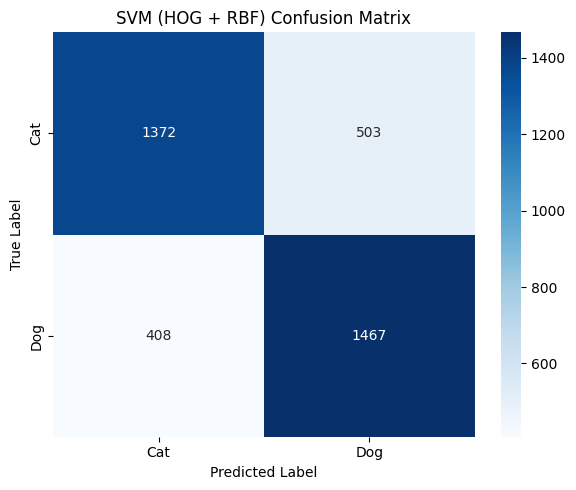

In [10]:
# CONFUSION MATRIX VISUALIZATION

cm = confusion_matrix(y_test, y_pred)
class_names = list(class_map.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("SVM (HOG + RBF) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save plot to results folder
cm_path = os.path.join(RESULTS_DIR, "svm_hog_confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

In [11]:
# SVM METRICS AND MODEL EXPORT

json_path = os.path.join(RESULTS_DIR, "svm_hog_metrics.json")
with open(json_path, "w") as f:
    json.dump(metrics, f, indent=4)

# Save trained model to disk
model_path = os.path.join(RESULTS_DIR, "best_svm_hog_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_svm, f)

print(f"\n[Export Complete] Saved:")
print(f" - Metrics JSON    : {json_path}")
print(f" - Model Pickle    : {model_path}")
print(f" - Confusion Matrix: {cm_path}")


[Export Complete] Saved:
 - Metrics JSON    : /content/results/svm_hog_metrics.json
 - Model Pickle    : /content/results/best_svm_hog_model.pkl
 - Confusion Matrix: /content/results/svm_hog_confusion_matrix.png


# Custom CNN

In [12]:
print("\n--- Custom CNN Model Training ---")

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 5 # Reduced for faster runtime; early stopping (patience=3) still applies

# Data Loaders for CNN - RGB images, normalized to [0,1]
# No data augmentation for validation/test sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROCESSED_DIR, 'train'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROCESSED_DIR, 'val'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROCESSED_DIR, 'test'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

# Get class names from one of the datasets
CLASS_NAMES = train_ds.class_names

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Normalize to [0,1]
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Data Augmentation layer (for training only)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Custom CNN Model Definition
def build_custom_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    model = tf.keras.Sequential([
        # Augmentation is applied only during training, integrated here for simplicity
        # but will be 'off' during validation/testing due to model.fit(train_ds) vs model.evaluate(val_ds)
        tf.keras.Input(shape=input_shape),
        data_augmentation,

        # Block 1
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 2
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 3
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Flatten and Dense layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5), # Add dropout for regularization
        tf.keras.layers.Dense(1, activation='sigmoid') # Binary classification
    ])
    return model

custom_cnn_model = build_custom_cnn()
custom_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

custom_cnn_model.summary()

# Calculate trainable parameter count
custom_cnn_param_count = custom_cnn_model.count_params()
print(f"Custom CNN Trainable Parameters: {custom_cnn_param_count}")


--- Custom CNN Model Training ---
Found 500 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,873 (98.36 MB)

 Trainable params: 25,783,873 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

Custom CNN Trainable Parameters: 25783873


In [13]:
# CLEAN INVALID/CORRUPT IMAGES (TensorFlow-strict check)
import tensorflow as tf

def clean_invalid_images(root_dir):
    removed = 0
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(root_dir, split)
        for cls in os.listdir(split_dir):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                try:
                    img_bytes = tf.io.read_file(fpath)
                    tf.io.decode_image(img_bytes, channels=3)
                except Exception:
                    os.remove(fpath)
                    removed += 1
    print(f"Removed {removed} invalid/corrupt images from {root_dir}")

clean_invalid_images(PROCESSED_DIR)

Removed 0 invalid/corrupt images from /content/processed_data


In [15]:
import os
import tensorflow as tf
import time
import shutil

cnn_training_time_seconds = 0.0
history = None

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 2

print("\nStarting Custom CNN training...")
start_cnn_train_time = time.time()

print("GPUs available:", tf.config.list_physical_devices('GPU'))

try:
    # Copy from Drive to local disk once per session — avoids Drive read latency
    LOCAL_PROCESSED_DIR = "/content/processed_data_local"
    if not os.path.exists(LOCAL_PROCESSED_DIR):
        print("Copying data from Drive to local disk...")
        shutil.copytree(PROCESSED_DIR, LOCAL_PROCESSED_DIR)
        print("Copy complete.")
    else:
        print("Local data already exists, skipping copy.")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL_PROCESSED_DIR, 'train'), labels='inferred', label_mode='binary',
        image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
        batch_size=BATCH_SIZE, shuffle=True, seed=SEED
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL_PROCESSED_DIR, 'val'), labels='inferred', label_mode='binary',
        image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
        batch_size=BATCH_SIZE, shuffle=False, seed=SEED
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL_PROCESSED_DIR, 'test'), labels='inferred', label_mode='binary',
        image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
        batch_size=BATCH_SIZE, shuffle=False, seed=SEED
    )

    CLASS_NAMES = train_ds.class_names

    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    AUTOTUNE = tf.data.AUTOTUNE
    # Cache to disk, not RAM
    train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache("/content/train_cache").prefetch(AUTOTUNE)
    val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache("/content/val_cache").prefetch(AUTOTUNE)
    test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache("/content/test_cache").prefetch(AUTOTUNE)

    history = custom_cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    )
except Exception as e:
    print(f"An error occurred during Custom CNN training: {e}")
finally:
    cnn_training_time_seconds = time.time() - start_cnn_train_time
    print(f"Custom CNN training (attempted) time: {cnn_training_time_seconds:.2f} seconds")


Starting Custom CNN training...
GPUs available: []
Copying data from Drive to local disk...
Copy complete.
Found 500 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Found 3750 files belonging to 2 classes.
Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 218s 14s/step - accuracy: 0.6260 - loss: 0.6480 - precision: 0.6235 - recall: 0.6360 - val_accuracy: 0.5651 - val_loss: 0.7778 - val_precision: 0.5405 - val_recall: 0.8677
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 199s 13s/step - accuracy: 0.6280 - loss: 0.6412 - precision: 0.6301 - recall: 0.6200 - val_accuracy: 0.5392 - val_loss: 0.7396 - val_precision: 0.5226 - val_recall: 0.9051
Custom CNN training (attempted) time: 421.96 seconds



Evaluating Custom CNN on Test set...
118/118 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.5421 - loss: 0.7405 - precision: 0.5241 - recall: 0.9179
Custom CNN Test Accuracy: 0.5421
Custom CNN Test Precision: 0.5241
Custom CNN Test Recall: 0.9179
Custom CNN Test F1-score: 0.6672


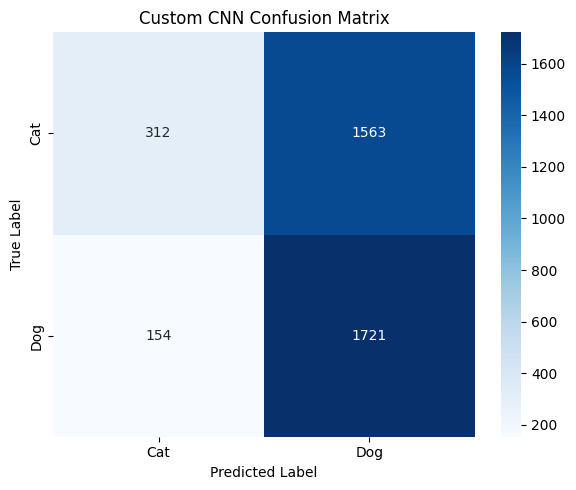

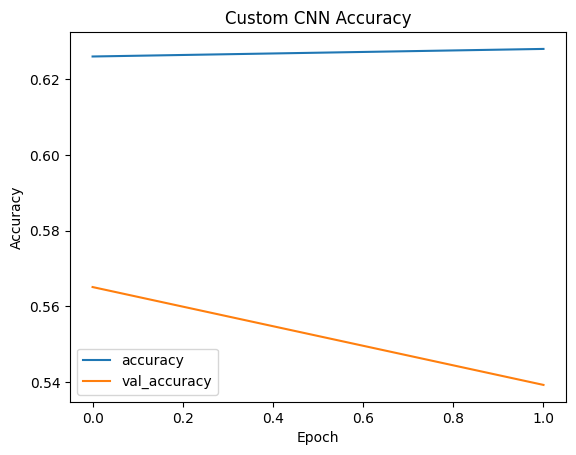

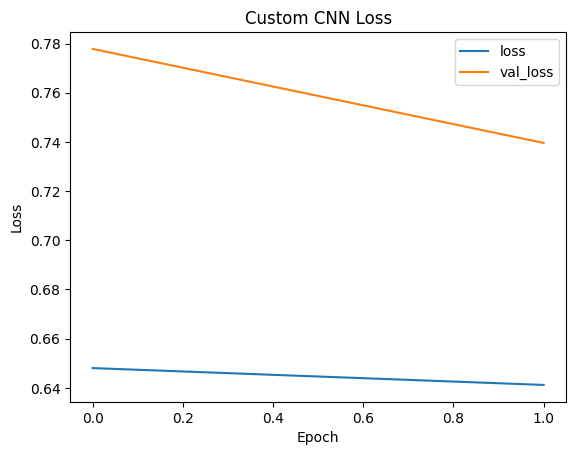


[Export Complete] Saved Custom CNN:
 - Metrics JSON    : /content/results/cnn_metrics.json
 - Model           : /content/results/custom_cnn_model.h5
 - Confusion Matrix: /content/results/cnn_confusion_matrix.png


In [16]:
# Evaluate Custom CNN on Test Set
print("\nEvaluating Custom CNN on Test set...")
cnn_test_loss, cnn_test_accuracy, cnn_test_precision, cnn_test_recall = custom_cnn_model.evaluate(test_ds)

# Calculate F1-score for CNN
cnn_test_f1 = 2 * (cnn_test_precision * cnn_test_recall) / (cnn_test_precision + cnn_test_recall + tf.keras.backend.epsilon())

print(f"Custom CNN Test Accuracy: {cnn_test_accuracy:.4f}")
print(f"Custom CNN Test Precision: {cnn_test_precision:.4f}")
print(f"Custom CNN Test Recall: {cnn_test_recall:.4f}")
print(f"Custom CNN Test F1-score: {cnn_test_f1:.4f}")

# Get predictions for confusion matrix
y_true_cnn = []
y_pred_cnn = []
for images, labels in test_ds:
    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend(custom_cnn_model.predict(images, verbose=0).flatten())

y_pred_cnn_binary = np.where(np.array(y_pred_cnn) > 0.5, 1, 0)
y_true_cnn = np.array(y_true_cnn)

cnn_cm = confusion_matrix(y_true_cnn, y_pred_cnn_binary)

# Store CNN metrics
cnn_metrics = {
    "accuracy": float(cnn_test_accuracy),
    "precision": float(cnn_test_precision),
    "recall": float(cnn_test_recall),
    "f1_score": float(cnn_test_f1),
    "training_time_seconds": float(cnn_training_time_seconds),
    "parameter_count": int(custom_cnn_param_count)
}

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cnn_cm_path = os.path.join(RESULTS_DIR, "cnn_confusion_matrix.png")
plt.savefig(cnn_cm_path, dpi=300)
plt.show()

# Plot Training History
hist_df = pd.DataFrame(history.history)
hist_df[['accuracy', 'val_accuracy']].plot(title="Custom CNN Accuracy");
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig(os.path.join(RESULTS_DIR, "cnn_accuracy_plot.png"), dpi=300)
plt.show()

hist_df[['loss', 'val_loss']].plot(title="Custom CNN Loss");
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(os.path.join(RESULTS_DIR, "cnn_loss_plot.png"), dpi=300)
plt.show()

# Export CNN metrics and model
cnn_json_path = os.path.join(RESULTS_DIR, "cnn_metrics.json")
with open(cnn_json_path, "w") as f:
    json.dump(cnn_metrics, f, indent=4)

cnn_model_path = os.path.join(RESULTS_DIR, "custom_cnn_model.h5")
custom_cnn_model.save(cnn_model_path)

print(f"\n[Export Complete] Saved Custom CNN:")
print(f" - Metrics JSON    : {cnn_json_path}")
print(f" - Model           : {cnn_model_path}")
print(f" - Confusion Matrix: {cnn_cm_path}")

# MobileNetV2 Transfer Learning

In [17]:
print("\n--- MobileNetV2 Transfer Learning ---")

# Data Loaders for MobileNetV2 - same as CNN, but will use ImageNet preprocessing
# Note: train_ds, val_ds, test_ds are already defined from Custom CNN section
# We will apply MobileNetV2 specific preprocessing in the model.

# --- Build MobileNetV2 Base Model ---
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BASE_MODEL_TRAINABLE_LAYERS = 20  # Number of top layers to unfreeze for fine-tuning

def build_mobilenetv2_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,  # Don't include the ImageNet classifier at the top
        weights='imagenet'
    )

    # Freeze the base model initially
    base_model.trainable = False

    # Create a classification head
    inputs = tf.keras.Input(shape=IMG_SHAPE)
    # MobileNetV2 expects input in range [-1, 1]
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)  # Ensure base model is not updated during head training
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenetv2_model()

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Higher LR for head training
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

mobilenet_model.summary()

mobilenet_initial_param_count = mobilenet_model.count_params()

# Fixed: trainable_weights are Variables, not layers — use their shape directly
trainable_param_count = sum(np.prod(w.shape) for w in mobilenet_model.trainable_weights)

print(f"MobileNetV2 (Head Only) Trainable Parameters: {trainable_param_count}")
print(f"MobileNetV2 Total Parameters: {mobilenet_initial_param_count}")


--- MobileNetV2 Transfer Learning ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 (Head Only) Trainable Parameters: 1281
MobileNetV2 Total Parameters: 2259265


In [20]:
# --- Phase 1: Train only the classification head ---
print("\nStarting MobileNetV2 Phase 1: Training Classification Head...")
start_mobilenet_train_time = time.time()

initial_epochs = 1  # Forced down for speed

history_head = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

# --- Phase 2: Fine-tune the top layers of the base model ---
print("\nStarting MobileNetV2 Phase 2: Fine-tuning Base Model Top Layers...")

# Unfreeze top layers of the base model
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-BASE_MODEL_TRAINABLE_LAYERS]:
    layer.trainable = False

# Recompile the model with a lower learning rate for fine-tuning
fine_tune_learning_rate = 0.0001
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

mobilenet_model.summary()

fine_tune_epochs = 1  # Forced down for speed
total_epochs = initial_epochs + fine_tune_epochs  # = 2

history_fine_tune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_head.epoch[-1],  # Start from where previous training left off
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

mobilenet_training_time_seconds = time.time() - start_mobilenet_train_time
print(f"MobileNetV2 total training time: {mobilenet_training_time_seconds:.2f} seconds")

# Get trainable parameter count after fine-tuning
mobilenet_fine_tune_param_count = mobilenet_model.count_params()
trainable_param_count = sum(np.prod(w.shape) for w in mobilenet_model.trainable_weights)
print(f"MobileNetV2 (Fine-tuned) Trainable Parameters: {trainable_param_count}")
print(f"MobileNetV2 Total Parameters: {mobilenet_fine_tune_param_count}")


Starting MobileNetV2 Phase 1: Training Classification Head...
16/16 ━━━━━━━━━━━━━━━━━━━━ 233s 15s/step - accuracy: 0.7420 - loss: 0.5006 - precision_2: 0.7490 - recall_2: 0.7280 - val_accuracy: 0.5000 - val_loss: 1.0159 - val_precision_2: 0.5000 - val_recall_2: 1.0000

Starting MobileNetV2 Phase 2: Fine-tuning Base Model Top Layers...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,207,361 (4.61 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 197s 12s/step - accuracy: 0.7360 - loss: 0.5295 - precision_3: 0.7379 - recall_3: 0.7320 - val_accuracy: 0.5000 - val_loss: 1.0570 - val_precision_3: 0.5000 - val_recall_3: 1.0000
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 186s 12s/step - accuracy: 0.7660 - loss: 0.4743 - precision_3: 0.7692 - recall_3: 0.7600 - val_accuracy: 0.5000 - val_loss: 1.0354 - val_precision_3: 0.5000 - val_recall_3: 1.0000
MobileNetV2 total training time: 616.42 seconds
MobileNetV2 (Fine-tuned) Trainable Parameters: 1207361
MobileNetV2 Total Parameters: 2259265



Evaluating MobileNetV2 on Test set...
MobileNetV2 Test Accuracy: 0.5000
MobileNetV2 Test Precision: 0.5000
MobileNetV2 Test Recall: 1.0000
MobileNetV2 Test F1-score: 0.6667


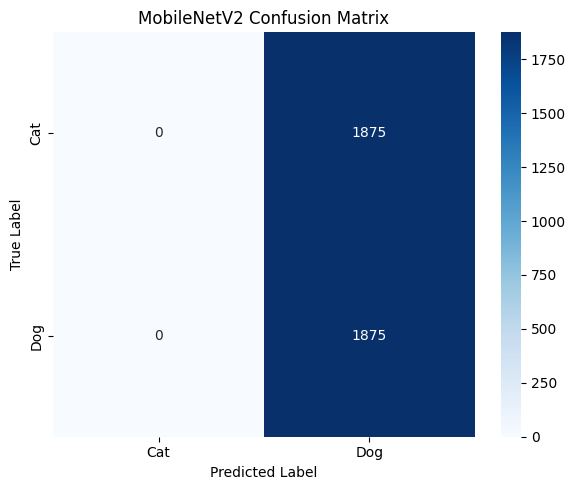

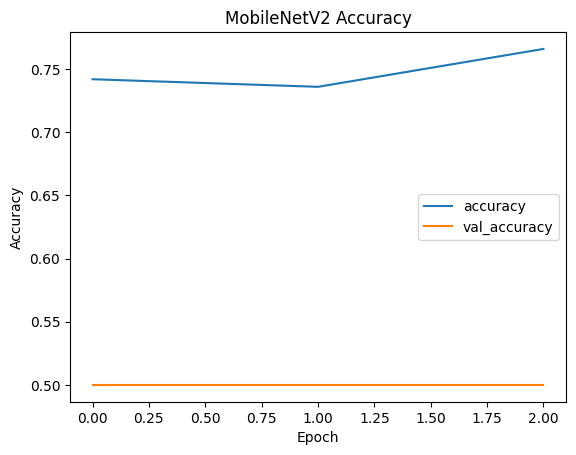

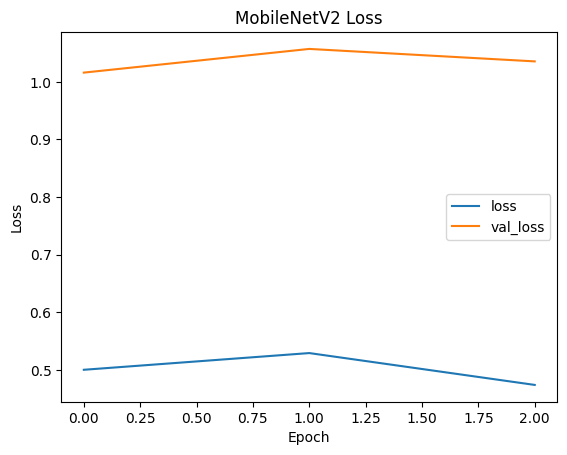


[Export Complete] Saved MobileNetV2:
 - Metrics JSON    : /content/results/mobilenetv2_metrics.json
 - Model           : /content/results/mobilenetv2_model.h5
 - Confusion Matrix: /content/results/mobilenetv2_confusion_matrix.png


In [22]:
# Evaluate MobileNetV2 on Test Set
print("\nEvaluating MobileNetV2 on Test set...")

# Single pass over test_ds — gets predictions once, computes all metrics from them
y_true_mobilenet = []
y_pred_mobilenet = []
for images, labels in test_ds:
    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(mobilenet_model.predict(images, verbose=0).flatten())

y_pred_mobilenet_binary = np.where(np.array(y_pred_mobilenet) > 0.5, 1, 0)
y_true_mobilenet = np.array(y_true_mobilenet)

mobilenet_test_accuracy = accuracy_score(y_true_mobilenet, y_pred_mobilenet_binary)
mobilenet_test_precision = precision_score(y_true_mobilenet, y_pred_mobilenet_binary)
mobilenet_test_recall = recall_score(y_true_mobilenet, y_pred_mobilenet_binary)
mobilenet_test_f1 = f1_score(y_true_mobilenet, y_pred_mobilenet_binary)

print(f"MobileNetV2 Test Accuracy: {mobilenet_test_accuracy:.4f}")
print(f"MobileNetV2 Test Precision: {mobilenet_test_precision:.4f}")
print(f"MobileNetV2 Test Recall: {mobilenet_test_recall:.4f}")
print(f"MobileNetV2 Test F1-score: {mobilenet_test_f1:.4f}")

mobilenet_cm = confusion_matrix(y_true_mobilenet, y_pred_mobilenet_binary)

# Store MobileNetV2 metrics
mobilenet_metrics = {
    "accuracy": float(mobilenet_test_accuracy),
    "precision": float(mobilenet_test_precision),
    "recall": float(mobilenet_test_recall),
    "f1_score": float(mobilenet_test_f1),
    "training_time_seconds": float(mobilenet_training_time_seconds),
    "parameter_count": int(mobilenet_fine_tune_param_count)  # Report total parameters after fine-tuning
}

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(mobilenet_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
mobilenet_cm_path = os.path.join(RESULTS_DIR, "mobilenetv2_confusion_matrix.png")
plt.savefig(mobilenet_cm_path, dpi=300)
plt.show()

# Plot Training History for MobileNetV2 (combined history from both phases)
# Using pd.concat instead of manual list-splicing — handles mismatched
# epoch counts between the two phases without crashing
hist_head_df = pd.DataFrame(history_head.history)
hist_fine_tune_df = pd.DataFrame(history_fine_tune.history) if history_fine_tune else pd.DataFrame()
hist_mobilenet_df = pd.concat([hist_head_df, hist_fine_tune_df], ignore_index=True)

hist_mobilenet_df[['accuracy', 'val_accuracy']].plot(title="MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig(os.path.join(RESULTS_DIR, "mobilenetv2_accuracy_plot.png"), dpi=300)
plt.show()

hist_mobilenet_df[['loss', 'val_loss']].plot(title="MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(os.path.join(RESULTS_DIR, "mobilenetv2_loss_plot.png"), dpi=300)
plt.show()

# Export MobileNetV2 metrics and model
mobilenet_json_path = os.path.join(RESULTS_DIR, "mobilenetv2_metrics.json")
with open(mobilenet_json_path, "w") as f:
    json.dump(mobilenet_metrics, f, indent=4)

mobilenet_model_path = os.path.join(RESULTS_DIR, "mobilenetv2_model.h5")
mobilenet_model.save(mobilenet_model_path)

print(f"\n[Export Complete] Saved MobileNetV2:")
print(f" - Metrics JSON    : {mobilenet_json_path}")
print(f" - Model           : {mobilenet_model_path}")
print(f" - Confusion Matrix: {mobilenet_cm_path}")

# Unified Comparison


--- Unified Comparison of Models ---

--- Model Comparison Table ---
                Accuracy  Precision  Recall  F1-score  Training Time (s)  \
Method                                                                     
HOG+SVM           0.7571     0.7447  0.7824    0.7631           229.2963   
Custom CNN        0.5421     0.5241  0.9179    0.6672           421.9637   
MobileNetV2 TL    0.5000     0.5000  1.0000    0.6667           616.4180   

               Parameter Count  
Method                          
HOG+SVM                    N/A  
Custom CNN            25783873  
MobileNetV2 TL         2259265  


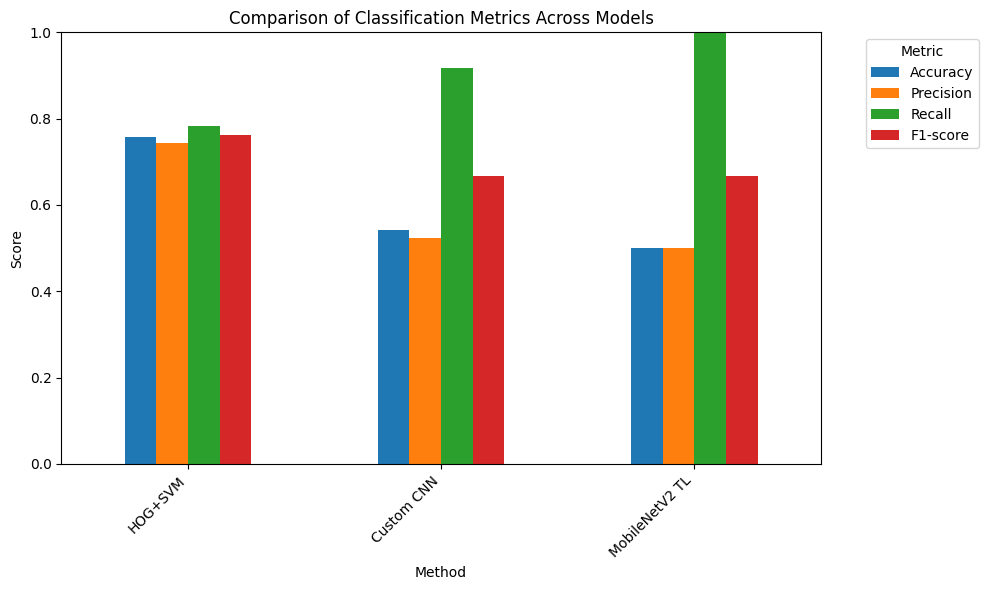

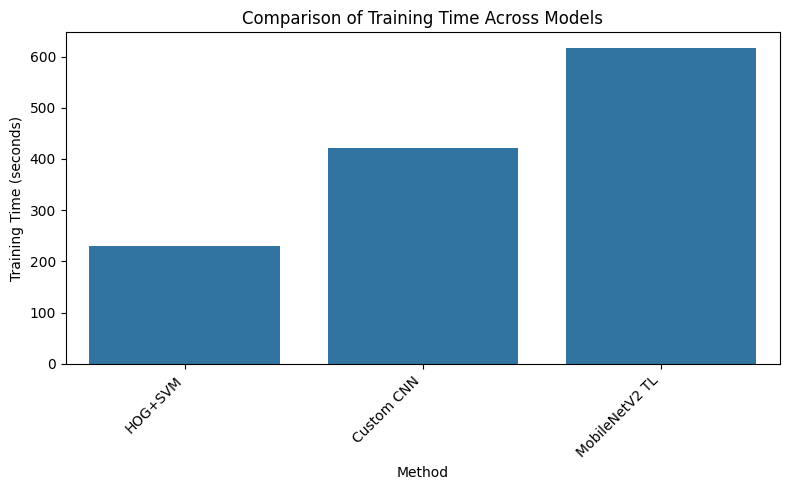


--- Model Performance Summary ---
The method with the highest accuracy is HOG+SVM with an accuracy of 0.7571.

80% Accuracy Threshold Check (threshold = 80.0%):
- HOG+SVM did NOT clear the 80.0% accuracy threshold (0.7571).
- Custom CNN did NOT clear the 80.0% accuracy threshold (0.5421).
- MobileNetV2 TL did NOT clear the 80.0% accuracy threshold (0.5000).

Accuracy vs. Training Time Trade-off:
- HOG+SVM: Achieved 0.7571 accuracy with a training time of 229.30 seconds and N/A parameters.
- Custom CNN: Achieved 0.5421 accuracy with a training time of 421.96 seconds and 25783873 parameters.
- MobileNetV2 TL: Achieved 0.5000 accuracy with a training time of 616.42 seconds and 2259265 parameters.

[Unified Comparison Complete] All results tabulated, visualized, and summarized.


In [23]:
print("\n--- Unified Comparison of Models ---")

import pandas as pd

# Load metrics from JSON files
def load_metrics(filename):
    filepath = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            return json.load(f)
    print(f"[Warning] Metrics file not found: {filepath}")
    return None

svm_hog_metrics = load_metrics("svm_hog_metrics.json")
cnn_metrics = load_metrics("cnn_metrics.json")
mobilenetv2_metrics = load_metrics("mobilenetv2_metrics.json")

# Prepare data for pandas DataFrame
comparison_data = []

if svm_hog_metrics:
    comparison_data.append({
        "Method": "HOG+SVM",
        "Accuracy": svm_hog_metrics.get("accuracy", np.nan),
        "Precision": svm_hog_metrics.get("precision", np.nan),
        "Recall": svm_hog_metrics.get("recall", np.nan),
        "F1-score": svm_hog_metrics.get("f1_score", np.nan),
        "Training Time (s)": svm_hog_metrics.get("training_time_seconds", np.nan),
        "Parameter Count": svm_hog_metrics.get("parameter_count", np.nan)
    })

if cnn_metrics:
    comparison_data.append({
        "Method": "Custom CNN",
        "Accuracy": cnn_metrics.get("accuracy", np.nan),
        "Precision": cnn_metrics.get("precision", np.nan),
        "Recall": cnn_metrics.get("recall", np.nan),
        "F1-score": cnn_metrics.get("f1_score", np.nan),
        "Training Time (s)": cnn_metrics.get("training_time_seconds", np.nan),
        "Parameter Count": cnn_metrics.get("parameter_count", np.nan)
    })

if mobilenetv2_metrics:
    comparison_data.append({
        "Method": "MobileNetV2 TL",
        "Accuracy": mobilenetv2_metrics.get("accuracy", np.nan),
        "Precision": mobilenetv2_metrics.get("precision", np.nan),
        "Recall": mobilenetv2_metrics.get("recall", np.nan),
        "F1-score": mobilenetv2_metrics.get("f1_score", np.nan),
        "Training Time (s)": mobilenetv2_metrics.get("training_time_seconds", np.nan),
        "Parameter Count": mobilenetv2_metrics.get("parameter_count", np.nan)
    })

comparison_df = pd.DataFrame(comparison_data)

if comparison_df.empty:
    print("\n[Error] No metrics files were found — nothing to compare yet.")
    print("Run the HOG+SVM, Custom CNN, and MobileNetV2 sections through to their export cells first.")
else:
    print("\n--- Model Comparison Table ---")
    print(comparison_df.set_index("Method").round(4))

    # --- Plot Grouped Bar Chart for Metrics ---
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    fig, ax = plt.subplots(figsize=(10, 6))
    comparison_df.set_index('Method')[metrics_to_plot].plot(kind='bar', ax=ax)
    plt.title('Comparison of Classification Metrics Across Models')
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "metrics_comparison_bar_chart.png"), dpi=300)
    plt.show()

    # --- Plot Bar Chart for Training Time ---
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Method', y='Training Time (s)', data=comparison_df)
    plt.title('Comparison of Training Time Across Models')
    plt.ylabel('Training Time (seconds)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "training_time_bar_chart.png"), dpi=300)
    plt.show()

    # --- Summary Text ---
    print("\n--- Model Performance Summary ---")

    highest_accuracy_method = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
    print(f"The method with the highest accuracy is {highest_accuracy_method['Method']} with an accuracy of {highest_accuracy_method['Accuracy']:.4f}.")

    threshold = 0.80
    print(f"\n80% Accuracy Threshold Check (threshold = {threshold*100}%):")
    for index, row in comparison_df.iterrows():
        if row['Accuracy'] >= threshold:
            print(f"- {row['Method']} cleared the {threshold*100}% accuracy threshold ({row['Accuracy']:.4f}).")
        else:
            print(f"- {row['Method']} did NOT clear the {threshold*100}% accuracy threshold ({row['Accuracy']:.4f}).")

    print("\nAccuracy vs. Training Time Trade-off:")
    for index, row in comparison_df.iterrows():
        print(f"- {row['Method']}: Achieved {row['Accuracy']:.4f} accuracy with a training time of {row['Training Time (s)']:.2f} seconds and {row['Parameter Count']} parameters.")

    print("\n[Unified Comparison Complete] All results tabulated, visualized, and summarized.")

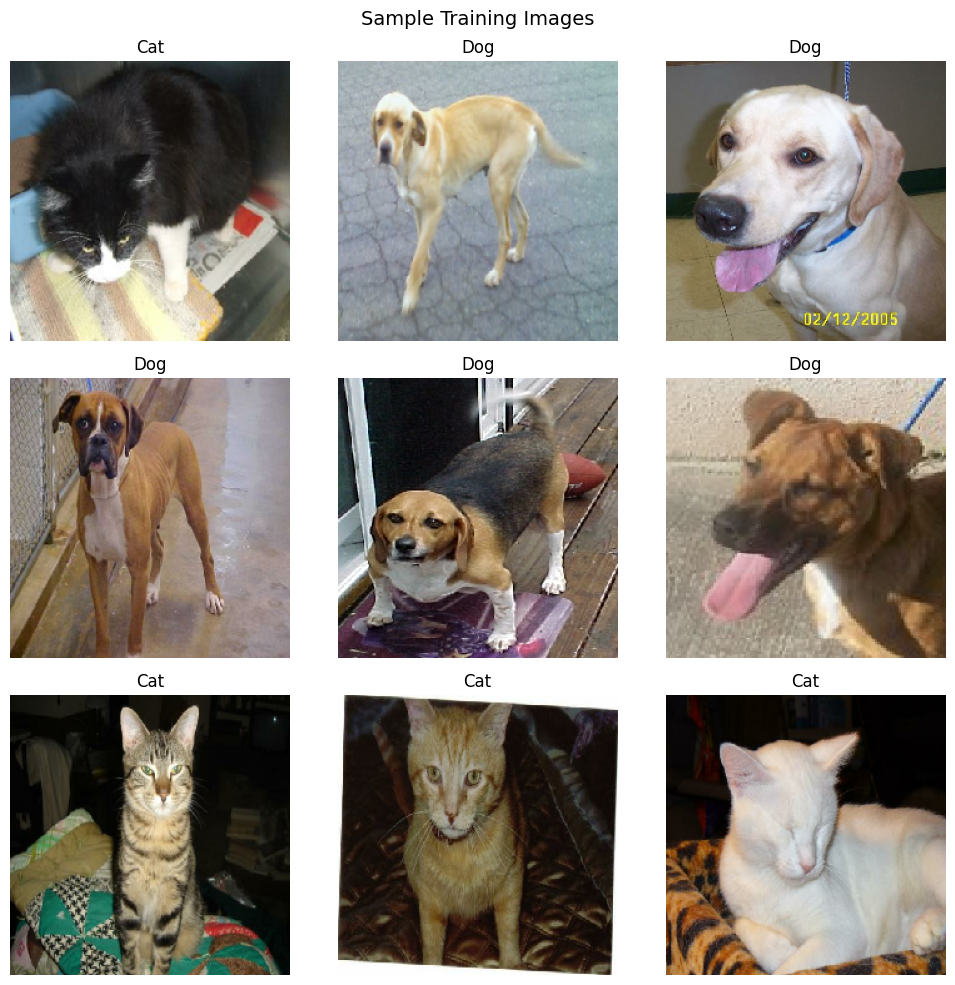

In [24]:
import matplotlib.pyplot as plt

# Show a grid of sample images from the training set
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # grab one batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())  # already normalized to [0,1] if preprocess() ran
        label = CLASS_NAMES[int(labels[i].numpy()[0])]
        plt.title(label)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sample_images_grid.png"), dpi=300)
plt.show()